### Bibliotecas e Frameworks

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from tensorflow import keras

2025-08-31 13:08:04.621045: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-31 13:08:04.675372: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-08-31 13:08:05.747593: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


### Questão 1

Implemente uma rede perceptron de múltiplas camadas e utilize-a para aproximar as funções abaixo.  

a. f(x) = log10(x), onde 1 ≤ x ≤ 10

b. f(x) = 10x^5 + 5x^4 + 2x^3 – 0.5x^2 + 3x + 2, onde 0 ≤ x ≤ 5

Para cada função a ser aproximada, gere um conjunto de treinamento e um conjunto de testes. 

Nesses conjuntos, cada amostra deve ser representada da seguinte forma: x é a entrada e f(x) é a saída desejada - rótulo. Treine um perceptron de múltiplas camadas para que ele aprenda a aproximar a função a partir do conjunto de treinamento, e vá testando com o conjunto de validação.  

Apresente os gráficos das funções reais vs. funções aproximadas e as curvas de erro de treinamento e validação.

#### Item a)

In [2]:
# Data

f = lambda x: np.log10(x)
X = np.linspace(1, 10, 10000).reshape(-1, 1)
y = f(X)

X_max = max(X)
X_normalized = X/X_max

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_normalized, y, test_size=0.35, random_state=42
)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

In [3]:
# Model

input_ = keras.layers.Input(shape=X_train.shape[1:])
hidden1 = keras.layers.Dense(100, activation="relu")(input_)
hidden2 = keras.layers.Dense(100, activation="relu")(hidden1)
hidden3 = keras.layers.Dense(100, activation="relu")(hidden2)
output = keras.layers.Dense(1, dtype="float64")(hidden3)

model = keras.Model(inputs=[input_], outputs=[output])
model.compile(loss="mse", optimizer="adam")
model.summary()

2025-08-31 13:08:05.978122: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,501 (80.48 KB)

 Trainable params: 20,501 (80.48 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# Train

history = model.fit(X_train, y_train, epochs=50, validation_data=(X_valid, y_valid))

# Prediction

y_pred = model.predict(X_test)

Epoch 1/50
 29/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1939    

2025-08-31 13:08:06.896600: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE
2025-08-31 13:08:06.924550: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE


163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0196 - val_loss: 0.0047
Epoch 2/50
 74/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0047

2025-08-31 13:08:07.350500: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE
2025-08-31 13:08:07.356141: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE


163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0038 - val_loss: 0.0016
Epoch 3/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1136e-04 - val_loss: 2.0971e-04
Epoch 4/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.5099e-04 - val_loss: 1.0670e-04
Epoch 5/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.3338e-05 - val_loss: 6.0946e-05
Epoch 6/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.4765e-05 - val_loss: 3.6804e-05
Epoch 7/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.9511e-05 - val_loss: 3.4417e-05
Epoch 8/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.4441e-05 - val_loss: 1.7919e-05
Epoch 9/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.5551e-05 - val_loss: 1.2594e-05
Epoch 10/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.3945e-05 - val_loss: 1.1612e-05
Epoch 11/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0913e-05 - val_loss: 8.1787e-06
Epoch 12/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9.0862e-06 - val

2025-08-31 13:08:23.506122: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE
2025-08-31 13:08:23.508842: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE
2025-08-31 13:08:23.600025: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE
2025-08-31 13:08:23.603279: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE


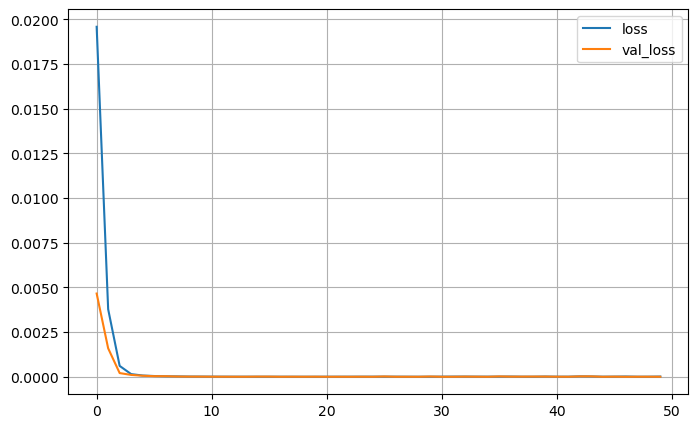

In [5]:
# Training Metrics

pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.show()

tf.Tensor(0.99993134, shape=(), dtype=float32)


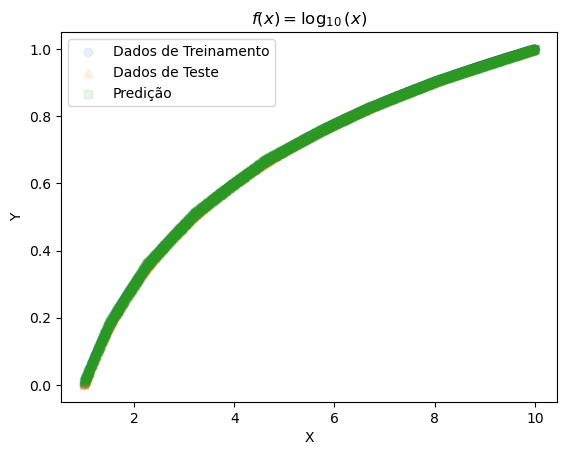

In [6]:
# Metrics

metric = keras.metrics.R2Score()
metric.update_state(y_test, y_pred)
result = metric.result()
print(result)

X_train_plot = X_train*X_max
X_test_plot = X_test*X_max

plt.figure()
plt.scatter(X_train_plot, y_train, alpha=0.1, label="Dados de Treinamento")
plt.scatter(X_test_plot, y_test, marker="^", alpha=0.1, label="Dados de Teste")
plt.scatter(X_test_plot, y_pred, marker="s", alpha=0.1, label="Predição")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.title(r"$f(x) = \log _{10}(x)$");


#### Item b)

In [7]:
# Data

f = lambda x: 10*x**5 + 5*x**4 + 2*x**3 - 0.5*x**2 + 3*x + 2
X = np.linspace(0, 5, 10000).reshape(-1,1)
y = f(X)

X_max = max(X)
X_normalized = X/X_max
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_normalized, y, test_size=0.35, random_state=42
)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

In [8]:
# Model

input_ = keras.layers.Input(shape=X_train.shape[1:])
hidden1 = keras.layers.Dense(100, activation="relu")(input_)
hidden2 = keras.layers.Dense(100, activation="relu")(hidden1)
hidden3 = keras.layers.Dense(100, activation="relu")(hidden2)
output = keras.layers.Dense(1, dtype="float64")(hidden3)

model = keras.Model(inputs=[input_], outputs=[output])
model.compile(loss="mse", optimizer="adam")
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,501 (80.48 KB)

 Trainable params: 20,501 (80.48 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Train

history = model.fit(X_train, y_train, epochs=100, validation_data=(X_valid, y_valid))

# Prediction

y_pred = model.predict(X_test)

Epoch 1/100
 61/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 123320344.0000   

2025-08-31 13:08:25.065908: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE
2025-08-31 13:08:25.099423: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE


163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 113542888.0000 - val_loss: 90808960.0000
Epoch 2/100
 85/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 92066584.0000

2025-08-31 13:08:25.472658: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE
2025-08-31 13:08:25.479068: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE


163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 72202672.0000 - val_loss: 52544600.0000
Epoch 3/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 53863520.0000 - val_loss: 45766128.0000
Epoch 4/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 45822968.0000 - val_loss: 37495532.0000
Epoch 5/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 36398960.0000 - val_loss: 28344680.0000
Epoch 6/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 26820018.0000 - val_loss: 19724836.0000
Epoch 7/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 18141164.0000 - val_loss: 12719859.0000
Epoch 8/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 11322727.0000 - val_loss: 8055339.5000
Epoch 9/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6933278.0000 - val_loss: 4786245.0000
Epoch 10/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4300049.5000 - val_loss: 2961838.0000
Epoch 11/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2782892.2500 - val_loss: 1958974.8750
Epoch 1

2025-08-31 13:08:58.423689: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE
2025-08-31 13:08:58.426629: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE
2025-08-31 13:08:58.518482: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE
2025-08-31 13:08:58.521007: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE


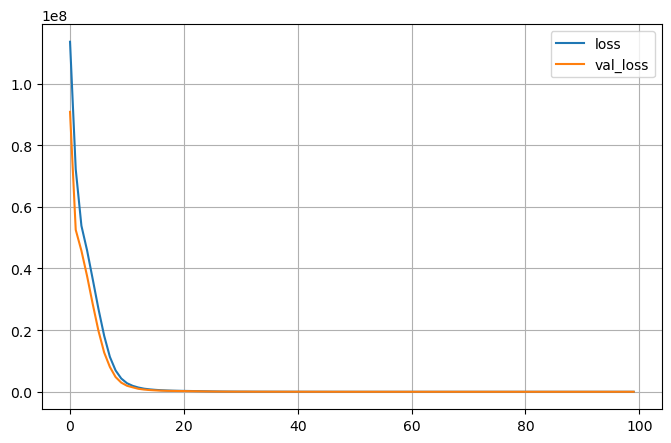

In [10]:
# Training Metrics

pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.show()

tf.Tensor(0.9999996, shape=(), dtype=float32)


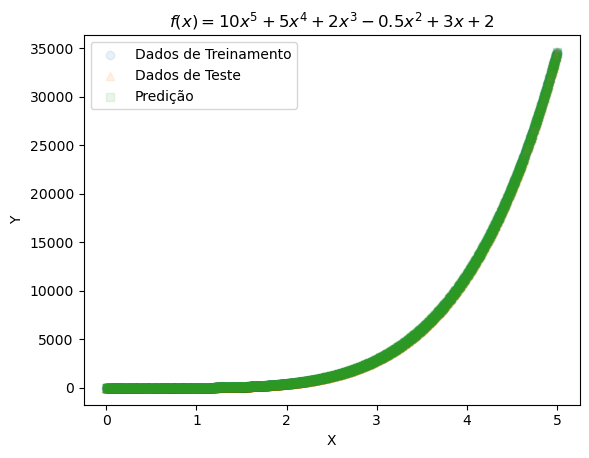

In [11]:
# Metrics

metric = keras.metrics.R2Score()
metric.update_state(y_test, y_pred)
result = metric.result()
print(result)

X_train_plot = X_train*X_max
X_test_plot = X_test*X_max

plt.figure()
plt.scatter(X_train_plot, y_train, alpha=0.1, label="Dados de Treinamento")
plt.scatter(X_test_plot, y_test, marker="^", alpha=0.1, label="Dados de Teste")
plt.scatter(X_test_plot, y_pred, marker="s", alpha=0.1, label="Predição")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.title(r"$f(x) = 10x^5 + 5x^4 + 2x^3 - 0.5x^2 + 3x + 2$");